# 环境导入

In [2]:
# 1. 环境准备与库导入
import warnings
warnings.filterwarnings('ignore')
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from matplotlib.ticker import MultipleLocator
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
from IPython.display import display, HTML


%matplotlib inline
plt.rcParams['font.sans-serif'] = ['SimHei'] # Windows 适用，Mac 请改为 'Arial Unicode MS'
plt.rcParams['axes.unicode_minus'] = False   # 正常显示负号

 # 数据加载与预览

In [3]:
input_path = './user_personalized_features.xlsx'


def load_and_preprocess(filepath):
    """
    加载 Excel 原始数据并进行基础的数据质量检查。

    Parameters:
    -----------
    filepath : str
        数据文件的本地或相对路径。

    Returns:
    --------
    df : pandas.DataFrame
        加载并经过基础检查后的数据框。
    """

    df = pd.read_excel(filepath)
    
    # 数据质量检查
    print(f"数据规模: {df.shape[0]} 行 x {df.shape[1]} 列")
    print(f"缺失值总数: {df.isnull().sum().sum()}")

    return df

# 执行数据加载
df = load_and_preprocess(input_path)
df.head()

数据规模: 1000 行 x 15 列
缺失值总数: 0


,Unnamed: 0,User_ID,Age,Gender,Location,Income,Interests,Last_Login_Days_Ago,Purchase_Frequency,Average_Order_Value,Total_Spending,Product_Category_Preference,Time_Spent_on_Site_Minutes,Pages_Viewed,Newsletter_Subscription
0,0,#1,56,Male,Suburban,38037,Sports,5,7,18,2546,Books,584,38,True
1,1,#2,46,Female,Rural,103986,Technology,15,7,118,320,Electronics,432,40,False
2,2,#3,32,Female,Suburban,101942,Sports,28,1,146,3766,Apparel,306,1,True
3,3,#4,60,Female,Suburban,71612,Fashion,18,3,163,4377,Apparel,527,29,False
4,4,#5,25,Male,Suburban,49725,Travel,2,5,141,4502,Health & Beauty,53,10,True


# 定义指标

In [4]:
def feature_engineering(df):
    """
    基于原始数据构建前置行为特征指标（探索度 E_Score 与摩擦力 Friction）。

    将用户的页面浏览和页面停留时长进行 Min-Max 归一化，
    并计算两者加权后的探索度；同时计算浏览量与购买频次的比值作为摩擦力。

    Parameters:
    -----------
    df : pandas.DataFrame
        包含基础行为数据（如浏览页数、停留时长、购买频次）的数据框。

    Returns:
    --------
    df : pandas.DataFrame
        新增 'Time_Spent_Norm', 'Pages_Viewed_Norm', 'E_Score', 'Friction' 列后的数据框。
    """


    # 基础RFM指标已在原始数据中给出
    
    #  E：探索度（Exploration）
    # 进行归一化处理
    scaler = MinMaxScaler(feature_range=(0, 100))
    df['Time_Spent_Norm'] = scaler.fit_transform(df[['Time_Spent_on_Site_Minutes']])
    df['Pages_Viewed_Norm'] = scaler.fit_transform(df[['Pages_Viewed']])

    # 定义探索度：I = 0.5 浏览页数 + 0.5 浏览时长
    df['E_Score'] = 0.5 * df['Time_Spent_Norm'] + 0.5 * df['Pages_Viewed_Norm']

    # 定义摩擦力系数 Friction：衡量用户平均每完成一次购买，需要看多少个页面（+1是为了防止分母为 0）
    df['Friction'] = df['Pages_Viewed'] / (df['Purchase_Frequency'] + 1)

    return df

df = feature_engineering(df)
df[['User_ID','E_Score','Friction']].head()

,User_ID,E_Score,Friction
0,#1,87.285385,4.750000
1,#2,76.638400,5.000000
2,#3,25.460637,0.500000
3,#4,73.136516,7.250000
4,#5,13.646357,1.666667


# EDA探索性数据分析

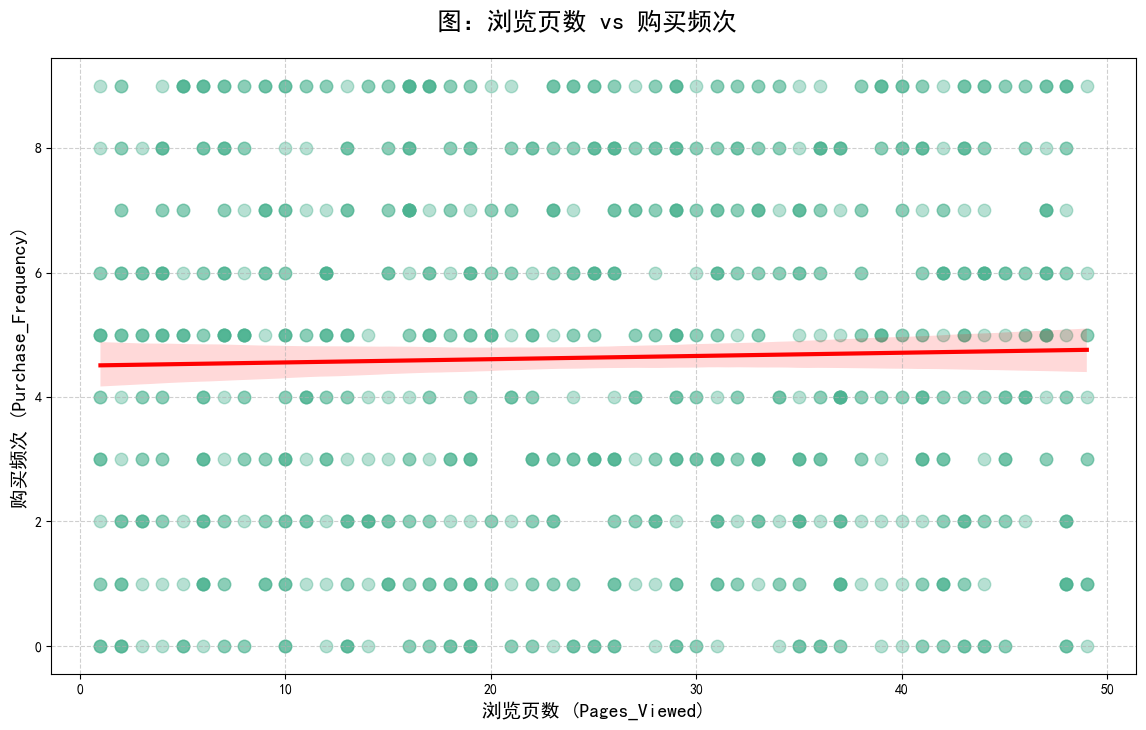

In [5]:
# 通过探索性分析，验证新提出的两个指标是否合理

def eda_validate_friction_hypothesis_large(df):

    """
    绘制浏览页数与购买频次的散点回归图，用于验证摩擦力假设的合理性。

    Parameters:
    -----------
    df : pandas.DataFrame
        包含 'Pages_Viewed' 和 'Purchase_Frequency' 字段的数据框。

    Returns:
    --------
    None
        直接在前端输出可视化图表。
    """

    plt.figure(figsize=(14, 8))
    sns.regplot(x='Pages_Viewed', y='Purchase_Frequency', data=df,
                scatter_kws={'alpha':0.4, 'color':'#4CB391', 's':80},
                line_kws={'color':'red', 'lw':3})
    plt.title('图：浏览页数 vs 购买频次 ', fontsize=18, pad=20)
    plt.xlabel('浏览页数 (Pages_Viewed)', fontsize=14)
    plt.ylabel('购买频次 (Purchase_Frequency)', fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.gca().xaxis.set_major_locator(MultipleLocator(10))
    plt.show()


# 调用函数
eda_validate_friction_hypothesis_large(df)

# 构建传统RFM模型

In [48]:

def build_rfm_model(df):

    """
    计算并标准化传统的 RFM (Recency, Frequency, Monetary) 得分。

    利用 MinMaxScaler 将最近登录天数、购买频次、总消费金额等原始数据
    映射至 0-100 的标准得分区间，其中最近登录天数取负值以保证得分正向意义。

    Parameters:
    -----------
    df : pandas.DataFrame
        包含原始 R、F、M 对应字段的数据框。

    Returns:
    --------
    df : pandas.DataFrame
        新增 'R_Score', 'F_Score', 'M_Score' 标准化得分列的数据框。
    """

    # 归一化处理
    scaler = MinMaxScaler(feature_range=(0, 100))

    df['R_Score'] = scaler.fit_transform(-df[['Last_Login_Days_Ago']])
    df['F_Score'] = scaler.fit_transform(df[['Purchase_Frequency']])
    df['M_Score'] = scaler.fit_transform(df[['Total_Spending']])

    return df

df = build_rfm_model(df)
df[['User_ID','R_Score','F_Score','M_Score','E_Score','Friction']].head()

,User_ID,R_Score,F_Score,M_Score,E_Score,Friction
0,#1,85.714286,77.777778,49.805607,87.285385,4.750000
1,#2,50.000000,77.777778,4.256190,76.638400,5.000000
2,#3,3.571429,11.111111,74.769797,25.460637,0.500000
3,#4,39.285714,33.333333,87.272355,73.136516,7.250000
4,#5,96.428571,55.555556,89.830162,13.646357,1.666667


# 精细化用户分层

In [49]:
# 使用K-means代替人工划分
def calculate_1d_kmeans_threshold(series):

    """
    使用一维 K-Means 算法对连续型变量进行聚类，计算业务分类的动态阈值。

    Parameters:
    -----------
    series : pandas.Series
        需要计算阈值的单列特征数据（如 R_Score, E_Score 等）。

    Returns:
    --------
    bound : float
        计算出的两个聚类中心的中点值，用作高低分层的分界线。
    """

    X = series.fillna(0).values.reshape(-1, 1)
    kmeans = KMeans(n_clusters=2, random_state=42, n_init=10).fit(X)
    centers = sorted(kmeans.cluster_centers_.flatten())
    bound = (centers[0] + centers[1]) / 2
    return bound

# 定义精细化分层函数
def classify_users(df):

    """
    基于基础 RFM 得分与动态阈值，结合探索度和摩擦力进行精细化用户分层。

    首先利用 K-Means 计算各项指标的高低阈值，进行传统的八大 RFM 基础打标；
    随后利用二维行为矩阵（探索度 x 摩擦力）将特定基础人群裂变为五大核心战略矩阵。

    Parameters:
    -----------
    df : pandas.DataFrame
        包含各项标准化得分（R, F, M, E, Friction）的数据框。

    Returns:
    --------
    df : pandas.DataFrame
        新增 'Base_Segment' (传统RFM标签) 和 'User_Segment' (最终精细化标签) 的数据框。
    segment_stats : pandas.DataFrame
        各分层人群的用户数、占比及核心指标均值的统计聚合看板。
    """

    # 分别计算各个指标的分界线
    r_bound = calculate_1d_kmeans_threshold(df['R_Score'])
    f_bound = calculate_1d_kmeans_threshold(df['F_Score'])
    m_bound = calculate_1d_kmeans_threshold(df['M_Score'])
    e_bound = calculate_1d_kmeans_threshold(df['E_Score'])
    fric_bound = calculate_1d_kmeans_threshold(df['Friction'])

    # 打印各个指标的分界线
    print(f"各个指标的分界线：")
    print(f"  R_Score 界线: {r_bound:.1f}")
    print(f"  F_Score 界线: {f_bound:.1f}")
    print(f"  M_Score 界线: {m_bound:.1f}")
    print(f"  E_Score 界线: {e_bound:.1f}")
    print(f"  Friction 界线: {fric_bound:.1f}")

    # 2. 核心分层逻辑
    def classify_user(row):
        r = row['R_Score']
        f = row['F_Score']
        m = row['M_Score']
        e = row['E_Score']
        friction = row['Friction']

        # 传统 RFM 分层
        if r >= r_bound and f >= f_bound and m >= m_bound: base_label = "重要价值用户"
        elif r >= r_bound and f < f_bound and m >= m_bound: base_label = "重要发展用户"
        elif r < r_bound and f >= f_bound and m >= m_bound: base_label = "重要保持用户"
        elif r < r_bound and f < f_bound and m >= m_bound: base_label = "重要挽留用户"
        elif r >= r_bound and f >= f_bound and m < m_bound: base_label = "一般价值用户"
        elif r >= r_bound and f < f_bound and m < m_bound: base_label = "一般发展用户"
        elif r < r_bound and f >= f_bound and m < m_bound: base_label = "一般保持用户"
        else: base_label = "低价值用户"

        # 精细化分层
        final_label = base_label # 默认情况下，最终标签等于基础标签

        high_m_labels = ["重要价值用户", "重要发展用户", "重要保持用户", "重要挽留用户"]


        # 1. 针对高 M 值用户
        if base_label in high_m_labels:
            if friction >= fric_bound:
                # 弱摩擦力高，视为高危预警
                final_label = "高危异动VIP"
            elif e >= e_bound and friction < fric_bound:
                # 爱逛且买得顺畅
                final_label = "深度互动用户"
            elif e < e_bound and friction < fric_bound:
                # 目的明确，买完就走
                final_label = "精准直购用户"

        # 2. 针对下沉用户的促转潜力挖掘
        elif base_label in ["低价值用户", "一般发展用户"] and e >= e_bound and friction < fric_bound:
            final_label = "高潜力用户"

        # 同时返回两个标签（转化为 Pandas Series 以便解包成两列）
        return pd.Series([base_label, final_label])

    # 执行分层函数
    df[['Base_Segment', 'User_Segment']] = df.apply(classify_user, axis=1)

    # 分层结果统计 (按最终的 User_Segment 统计)
    segment_stats = df.groupby(['Base_Segment', 'User_Segment']).agg({
    'User_ID': 'count',
    'Total_Spending': 'mean',
    'Purchase_Frequency': 'mean',
    'E_Score': 'mean',
    'Friction': 'mean'
        }).round(2)

    # 修改列名
    segment_stats.columns = ['用户数', '平均消费', '平均购买频率', '平均意向分', '平均摩擦力系数']

    # 计算百分比（注意这里是占大盘总数的比例）
    segment_stats['占比(%)'] = (segment_stats['用户数'] / len(df) * 100).round(1)

    # 为了让展示更美观，我们可以在不破坏层级的情况下进行排序
    # 优先按 Base_Segment 排序（你可以根据需求调整顺序），再按用户数排序
    segment_stats = segment_stats.sort_values(['Base_Segment', '用户数'], ascending=[True, False])

    print("\n用户分层统计:")
    display(HTML(segment_stats.to_html()))

    return df, segment_stats

# 运行函数
df, segment_stats = classify_users(df)

各个指标的分界线：
  R_Score 界线: 48.4
  F_Score 界线: 49.9
  M_Score 界线: 50.3
  E_Score 界线: 49.3
  Friction 界线: 16.3

用户分层统计:


# 用户分层结果可视化

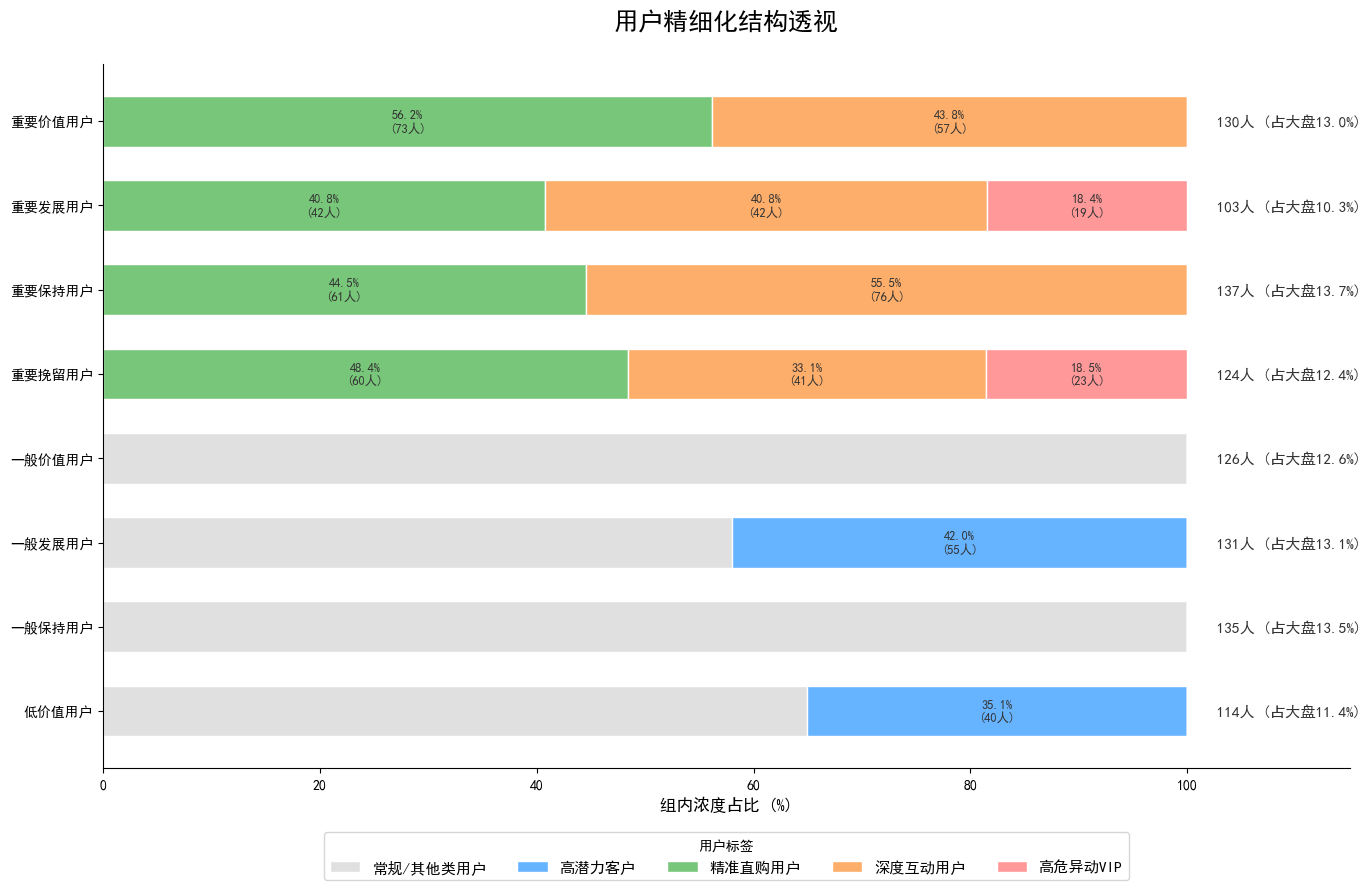

In [50]:
def plot_strategic_segments_matrix_100pct(df):
    """
        绘制 100% 组内归一化横向堆叠条形图，透视用户精细化结构。

        消除底层庞大常规用户群绝对数量造成的“视觉坍塌”，将横轴统一为“组内浓度占比”，
        聚焦展示四大重点战略人群在各 RFM 阶层内部的真实分布占比。

        Parameters:
        -----------
        df : pandas.DataFrame
            包含最终分层结果 'Base_Segment' 和 'User_Segment' 的数据框。

        Returns:
        --------
        None
            直接在前端输出交互式或静态图表。
        """

    # 1. 标签归纳映射
    def categorize_for_plot(label):
        if '高危异动VIP' in label:
            return '高危异动VIP'
        elif '深度互动用户' in label:
            return '深度互动用户'
        elif '精准直购用户' in label:
            return '精准直购用户'
        elif '高潜力' in label:
            return '高潜力客户'
        else:
            return '常规/其他类用户'

    df['Plot_Category'] = df['User_Segment'].apply(categorize_for_plot)

    # 2. 创建交叉表
    plot_data = pd.crosstab(df['Base_Segment'], df['Plot_Category'])

    # 预定顺序
    plot_cols = ['常规/其他类用户', '高潜力客户', '精准直购用户', '深度互动用户', '高危异动VIP']
    for col in plot_cols:
        if col not in plot_data.columns:
            plot_data[col] = 0

    plot_data = plot_data[plot_cols]

    # RFM 顺序重排
    rfm_order = [
        "重要价值用户", "重要发展用户", "重要保持用户", "重要挽留用户",
        "一般价值用户", "一般发展用户", "一般保持用户", "低价值用户"
    ]
    plot_data = plot_data.reindex(rfm_order[::-1]).fillna(0)
    total_users = len(df)

    # ================= 核心修改区域 =================
    # 提前算出每一层（每一行）的总人数
    row_totals = plot_data.sum(axis=1)

    fig, ax = plt.subplots(figsize=(14, 9))

    colors = {
        '常规/其他类用户': '#e0e0e0',
        '高潜力客户': '#66b3ff',
        '精准直购用户': '#78c679',
        '深度互动用户': '#fdae6b',
        '高危异动VIP': '#ff9999'
    }

    # 左侧起始位置（现在它是按百分比累加的，从 0.0 开始）
    left_pos = pd.Series([0.0] * len(plot_data), index=plot_data.index)

    for category in plot_cols:
        values = plot_data[category] # 这是绝对人数
        # 计算该类别在这一行中的百分比占比 (0-100)
        pct_values = (values / row_totals) * 100

        # 画图时使用百分比作为长度 (pct_values)
        ax.barh(plot_data.index, pct_values, left=left_pos,
               label=category, color=colors[category], edgecolor='white', height=0.6)

        # 内部文字标签逻辑
        if category != '常规/其他类用户':
            for i, val in enumerate(values):
                if val > 0:
                    pct = pct_values.iloc[i] # 直接取刚才算好的百分比
                    # X轴文字位置也必须基于百分比来定位
                    x_pos = left_pos.iloc[i] + pct / 2

                    if pct > 1.5:
                        ax.text(x_pos, i, f'{pct:.1f}%\n({int(val)}人)',
                                ha='center', va='center', color='#333333', fontsize=9, fontweight='bold')

        # 累加左侧位置（用百分比累加）
        left_pos += pct_values

    # 4. 最右侧文字：所有柱子现在都到100%就齐平了，所以固定在102%的位置写总人数
    for i, (idx, row) in enumerate(plot_data.iterrows()):
        total_bar = row.sum()
        pct_total = (total_bar / total_users) * 100
        # 固定在 x=102 的位置打上标签
        ax.text(102, i, f' {int(total_bar)}人 (占大盘{pct_total:.1f}%)',
                ha='left', va='center', color='#333333', fontsize=11, fontweight='bold')

    # ================================================

    # 5. 图表装饰与美化
    # X轴的范围固定为 0 到 115（多留15%的空间给最右侧的文字）
    ax.set_xlim(0, 115)

    plt.title('用户精细化结构透视', fontsize=18, pad=25, fontweight='bold')
    # 更改X轴的单位
    plt.xlabel('组内浓度占比 (%)', fontsize=12)
    plt.ylabel('', fontsize=12)

    plt.legend(title='用户标签', bbox_to_anchor=(0.5, -0.08), loc='upper center', ncol=5, fontsize=11)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.show()

# 调用全新的 100% 堆叠图函数
plot_strategic_segments_matrix_100pct(df)

# 检验新模型

## 导入检验数据集

In [51]:
df_raw = pd.read_csv('my_cohort_data_Oct_Nov.csv')

## 对10月份用户进行分层

### 计算基础 RFM 指标

In [52]:
df_raw['event_time'] = pd.to_datetime(df_raw['event_time'])

# 提取 10 月份的数据作为观察期来给用户打标签
df_oct = df_raw[df_raw['event_time'].dt.month == 10].copy()

# 11 月份的数据作为验证，在这里先存起来不参与任何计算
df_nov = df_raw[df_raw['event_time'].dt.month == 11].copy()

print(f"10月数据量(用于观察): {len(df_oct)}条，11月数据量(用于验证): {len(df_nov)}条。")

# “今天”定为 10 月份的最后一天
max_date = df_oct['event_time'].max()

# 原始数据没有“停留时间”这一指标，需要估算
# 按用户和时间排序
df_oct = df_oct.sort_values(['user_id', 'event_time'])

# 计算行为间的时间差
df_oct['prev_time'] = df_oct.groupby('user_id')['event_time'].shift(1)
df_oct['time_diff'] = (df_oct['event_time'] - df_oct['prev_time']).dt.total_seconds()

# 如果时间差 < 1800秒（30分钟），认为是有效停留，否则计为0
df_oct['active_duration'] = df_oct['time_diff'].apply(lambda x: x if x < 1800 else 0)

# 聚合计算总时长
user_duration = df_oct.groupby('user_id')['active_duration'].sum().reset_index()
user_duration.columns = ['user_id', 'Estimated_Time']

# 分离购买行为和浏览行为
purchase_df = df_oct[df_oct['event_type'] == 'purchase']
view_df = df_oct[df_oct['event_type'] == 'view']

# 聚合计算：构建基础 RFM 与 探索度
rfm = purchase_df.groupby('user_id').agg(
    Last_Purchase=('event_time', 'max'),
    Purchase_Frequency=('event_type', 'count'),
    Total_Spending=('price', 'sum')
).reset_index()
rfm['Recency_Days'] = (max_date - rfm['Last_Purchase']).dt.days

views = view_df.groupby('user_id').agg(
    Pages_Viewed=('event_type', 'count')
).reset_index()

# 4. 把所有特征拼接到一张用户底表上
df_features = pd.DataFrame({'user_id': df_oct['user_id'].unique()})
df_features = df_features.merge(user_duration, on='user_id', how='left')
df_features = df_features.merge(rfm, on='user_id', how='left')
df_features = df_features.merge(views, on='user_id', how='left')

# 填补空值
df_features['Purchase_Frequency'] = df_features['Purchase_Frequency'].fillna(0)
df_features['Total_Spending'] = df_features['Total_Spending'].fillna(0)
df_features['Pages_Viewed'] = df_features['Pages_Viewed'].fillna(0)

# 未购买用户的 R 值设为一个较大的值
max_recency = (max_date - df_oct['event_time'].min()).days + 30
df_features['Recency_Days'] = df_features['Recency_Days'].fillna(max_recency)

# 标准化打分
scaler = MinMaxScaler(feature_range=(0, 100))
df_features['R_Score'] = scaler.fit_transform(-df_features[['Recency_Days']])
df_features['F_Score'] = scaler.fit_transform(df_features[['Purchase_Frequency']])
df_features['M_Score'] = scaler.fit_transform(df_features[['Total_Spending']])

# 输出汇总表格
summary_data = []
metrics_map = [
    ('Recency (最近购买天数)', 'Recency_Days', 'R_Score'),
    ('Frequency (购买频次)', 'Purchase_Frequency', 'F_Score'),
    ('Monetary (消费金额)', 'Total_Spending', 'M_Score')
]

for name, raw_col, score_col in metrics_map:
    summary_data.append({
        '指标名称': name,
        '原始数据_Min': df_features[raw_col].min(),
        '原始数据_Max': df_features[raw_col].max(),
        '标准得分_Min': df_features[score_col].min(),
        '标准得分_Max': df_features[score_col].max()
    })

summary_df = pd.DataFrame(summary_data).round(2) # 保留两位小数，让展示更整洁

print("\n📊 RFM 指标标准化前后极值汇总表:")
display(HTML(summary_df.to_html(index=False)))

10月数据量(用于观察): 308850条，11月数据量(用于验证): 259377条。

📊 RFM 指标标准化前后极值汇总表:


指标名称,原始数据_Min,原始数据_Max,标准得分_Min,标准得分_Max
Recency (最近购买天数),0.0,60.00,0.0,100.0
Frequency (购买频次),0.0,121.00,0.0,100.0
Monetary (消费金额),0.0,80724.36,0.0,100.0


### RFM 分布可视化 （原始数据）

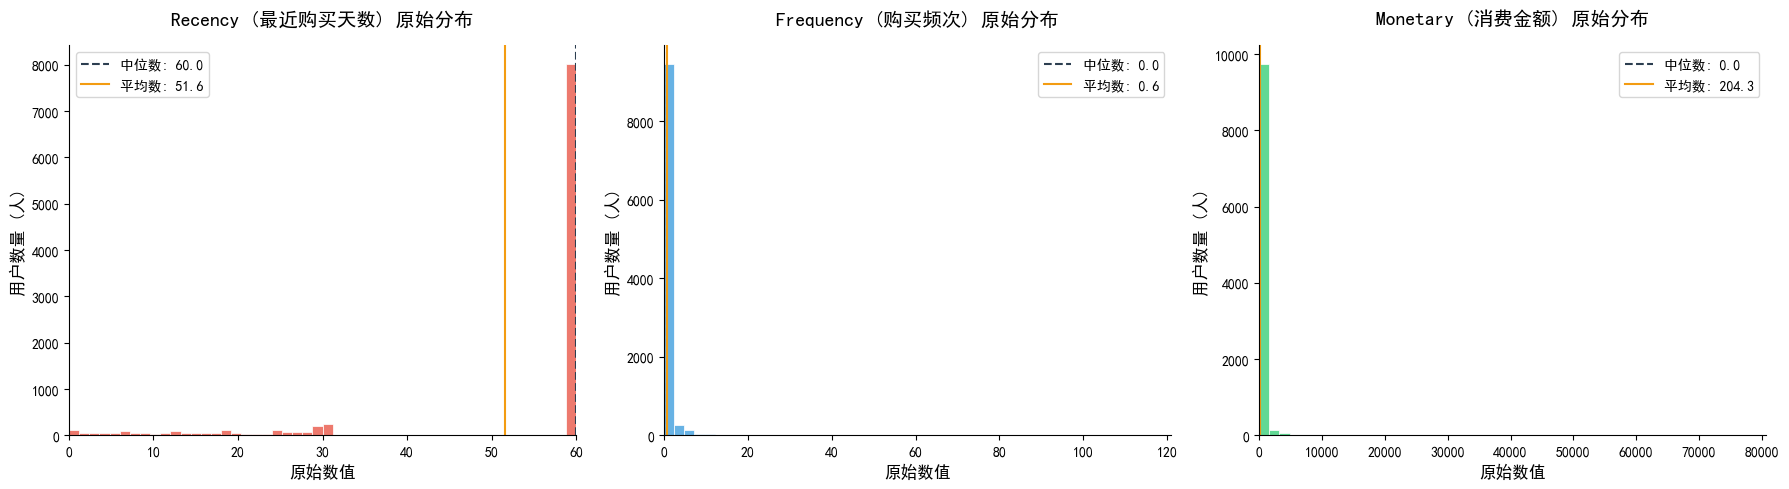

In [53]:
def plot_rfm_distributions(df):
    """
    绘制原始 R、F、M 核心业务特征的分布直方图。

    通过自适应 X 轴边界并标记均值与中位数，直观展示底层电商数据的长尾偏态分布。

    Parameters:
    -----------
    df : pandas.DataFrame
        包含 'Recency_Days', 'Purchase_Frequency', 'Total_Spending' 的数据框。

    Returns:
    --------
    None
        直接在前端输出可视化图表。
    """
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # 定义指标及其对应的图表标题和主题色 (保持和标准化得分图一致的色系)
    metrics = [
        ('Recency_Days', 'Recency (最近购买天数)', '#e74c3c'),   # 红色
        ('Purchase_Frequency', 'Frequency (购买频次)', '#3498db'),   # 蓝色
        ('Total_Spending', 'Monetary (消费金额)', '#2ecc71')    # 绿色
    ]

    for i, (col, title, color) in enumerate(metrics):
        # 1. 去掉 kde=True，设置 bins=50 显示更精细的分布
        sns.histplot(df[col], kde=False, ax=axes[i], color=color, bins=50, edgecolor='white')

        # 图表美化
        axes[i].set_title(f'{title} 原始分布', fontsize=14, fontweight='bold', pad=15)
        axes[i].set_xlabel('原始数值', fontsize=12)
        axes[i].set_ylabel('用户数量 (人)', fontsize=12)

        # 2. 动态获取最小值和最大值，卡紧 X 轴边界，消除空白
        data_min = df[col].min()
        data_max = df[col].max()
        axes[i].set_xlim(data_min, data_max)

        # 标注中位数和平均值
        median_val = df[col].median()
        mean_val = df[col].mean()
        axes[i].axvline(median_val, color='#2c3e50', linestyle='--', linewidth=1.5, label=f'中位数: {median_val:.1f}')
        axes[i].axvline(mean_val, color='#f39c12', linestyle='-', linewidth=1.5, label=f'平均数: {mean_val:.1f}')
        axes[i].legend()

        # 去除顶部和右侧边框
        axes[i].spines['top'].set_visible(False)
        axes[i].spines['right'].set_visible(False)

    plt.tight_layout()
    plt.show()

# 调用函数查看原始数据的分布
plot_rfm_distributions(df_features)

### RFM 分布可视化（标准化）

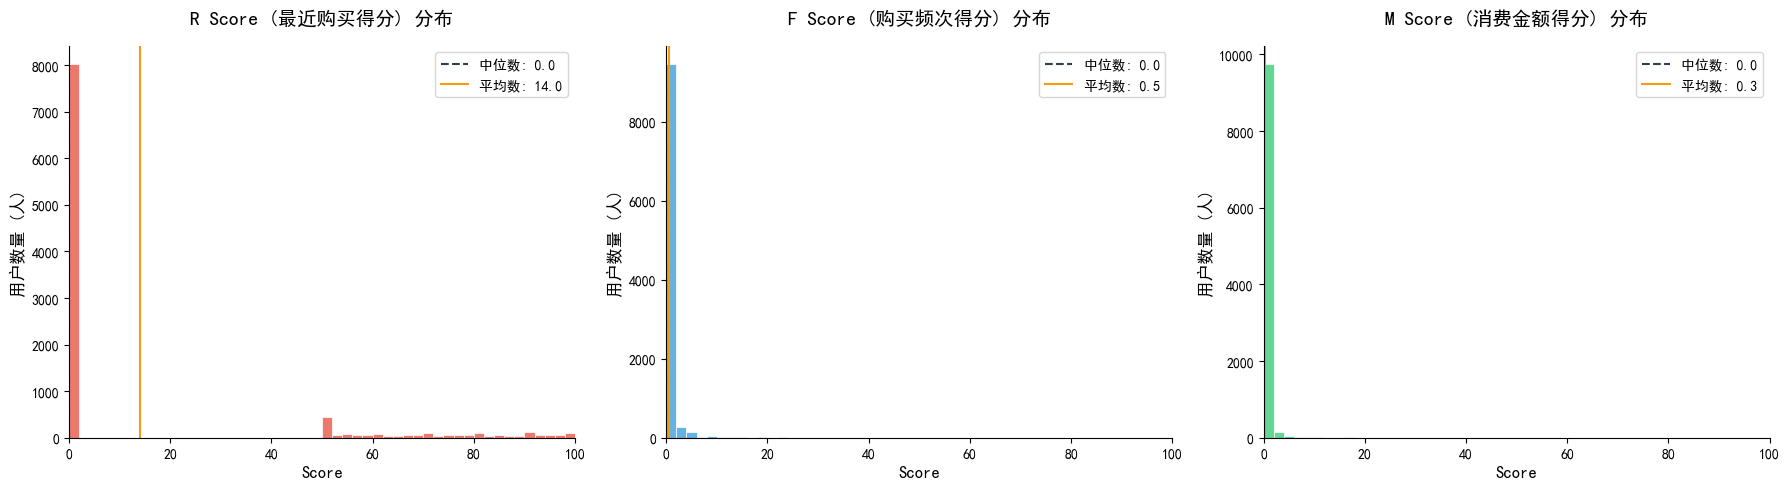

In [54]:
def plot_rfm_scores_distributions(df):
    """
    绘制标准化后的 R_Score、F_Score、M_Score 得分分布直方图。

    Parameters:
    -----------
    df : pandas.DataFrame
        包含标准化后得分字段的数据框。

    Returns:
    --------
    None
        直接在前端输出可视化图表。
    """
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # 定义指标及其对应的图表标题和颜色
    metrics = [
        ('R_Score', 'R Score (最近购买得分)', '#e74c3c'),   # 红色
        ('F_Score', 'F Score (购买频次得分)', '#3498db'),   # 蓝色
        ('M_Score', 'M Score (消费金额得分)', '#2ecc71')    # 绿色
    ]

    for i, (col, title, color) in enumerate(metrics):
        # 1. 去掉 kde=True，并将 bins 增加到 50 以显示更精细的区间
        sns.histplot(df[col], kde=False, ax=axes[i], color=color, bins=50, edgecolor='white')

        # 图表美化
        axes[i].set_title(f'{title} 分布', fontsize=14, fontweight='bold', pad=15)
        axes[i].set_xlabel('Score', fontsize=12)
        axes[i].set_ylabel('用户数量 (人)', fontsize=12)

        # 2. 动态获取该列数据的最小值和最大值，作为 X 轴的边界
        data_min = df[col].min()
        data_max = df[col].max()
        axes[i].set_xlim(data_min, data_max)

        # 标注中位数和平均值
        median_val = df[col].median()
        mean_val = df[col].mean()
        axes[i].axvline(median_val, color='#2c3e50', linestyle='--', linewidth=1.5, label=f'中位数: {median_val:.1f}')
        axes[i].axvline(mean_val, color='#f39c12', linestyle='-', linewidth=1.5, label=f'平均数: {mean_val:.1f}')
        axes[i].legend()

        # 去除顶部和右侧的边框线
        axes[i].spines['top'].set_visible(False)
        axes[i].spines['right'].set_visible(False)

    plt.tight_layout()
    plt.show()

# 调用函数查看标准化得分的分布
plot_rfm_scores_distributions(df_features)

### 用户分层

In [55]:

# 计算指标：摩擦力
df_features['Friction'] = df_features['Pages_Viewed'] / (df_features['Purchase_Frequency'] + 1)

# 计算指标：探索度
# 归一化
scaler = MinMaxScaler(feature_range=(0, 100))

view_score = scaler.fit_transform(df_features[['Pages_Viewed']])
time_score = scaler.fit_transform(df_features[['Estimated_Time']])

df_features['E_Score'] = 0.5 * view_score.flatten() + 0.5 * time_score.flatten()


# 统一列名
df_features.rename(columns={'user_id': 'User_ID'}, inplace=True)
# 调用分层函数
final_df, stats = classify_users(df_features)


各个指标的分界线：
  R_Score 界线: 35.3
  F_Score 界线: 14.7
  M_Score 界线: 32.4
  E_Score 界线: 9.6
  Friction 界线: 72.4

用户分层统计:


### 分层结果可视化

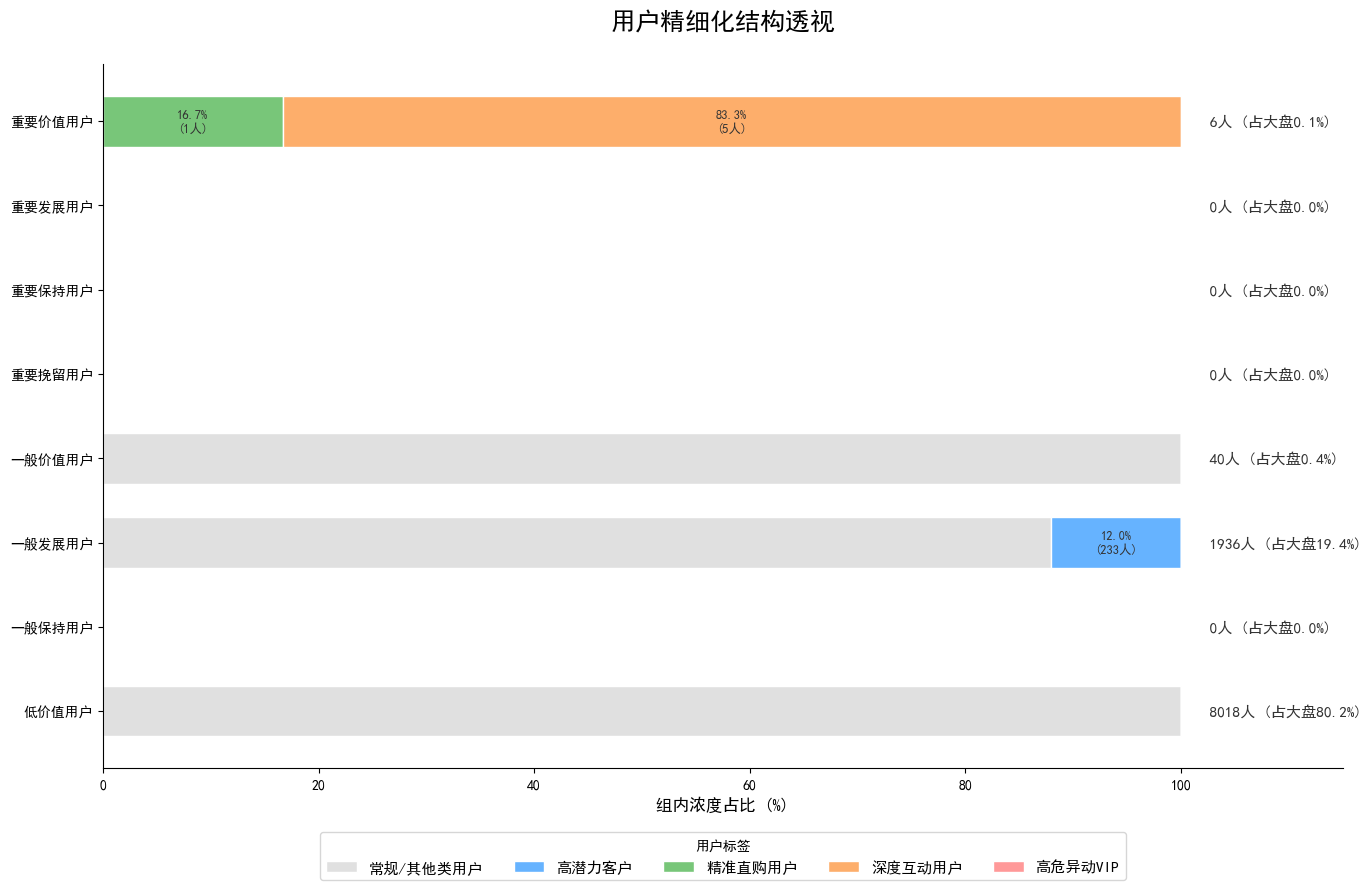

In [56]:
plot_strategic_segments_matrix_100pct(final_df)

## 时间回溯验证（11月）

In [57]:

# 改回列名
df_features.rename(columns={'User_ID': 'user_id'}, inplace=True)

# 提取重点关注的目标用户 user_id 列表
target_potential_ids = final_df[final_df['User_Segment'].str.contains('高潜力', na=False)]['user_id'].unique()

# 注意：常规下沉用户的标签通常保留在基础 RFM 划分中，建议从 Base_Segment 提取更稳妥
control_regular_ids = final_df[final_df['Base_Segment'].isin(['一般发展用户', '低价值用户'])]['user_id'].unique()

# VIP 行为矩阵细分提取
target_risk_vip_ids = final_df[final_df['User_Segment'].str.contains('高危异动', na=False)]['user_id'].unique()
target_immersive_vip_ids = final_df[final_df['User_Segment'].str.contains('深度互动', na=False)]['user_id'].unique()
target_efficient_vip_ids = final_df[final_df['User_Segment'].str.contains('精准直购', na=False)]['user_id'].unique()

print("目标人群数量如下：")
print(f" 高潜力客户: {len(target_potential_ids)}人")
print(f" 高危异动VIP: {len(target_risk_vip_ids)}人")
print(f" 深度互动用户: {len(target_immersive_vip_ids)}人")
print(f" 精准直购用户: {len(target_efficient_vip_ids)}人")

# 定义评估函数
def evaluate_nov_performance(user_list, group_name):
    # 拿 10 月圈定的名单，去 11 月的数据里匹配
    group_nov_data = df_nov[df_nov['user_id'].isin(user_list)]
    nov_purchases = group_nov_data[group_nov_data['event_type'] == 'purchase']

    total_users = len(user_list)
    if total_users == 0: return None

    # 指标计算
    active_users = group_nov_data['user_id'].nunique() # 11月回访人数
    buyers = nov_purchases['user_id'].nunique()        # 11月下单人数

    conversion_rate = buyers / total_users             # 11月真实转化率
    total_revenue = nov_purchases['price'].sum()       # 11月贡献总营收
    avg_revenue_per_buyer = total_revenue / buyers if buyers > 0 else 0

    return {
        '人群分组': group_name,
        '10月圈定人数': total_users,
        '11月回访人数': active_users,
        '11月下单人数': buyers,
        '11月真实转化率': f"{conversion_rate:.2%}",
        '11月贡献总营收': round(total_revenue, 2),
        '11月买家平均客单价': round(avg_revenue_per_buyer, 2)
    }

# 执行评估对比
results = []
results.append(evaluate_nov_performance(target_potential_ids, "高潜力客户 "))
results.append(evaluate_nov_performance(control_regular_ids, "一般/低价值 "))
results.append(evaluate_nov_performance(target_risk_vip_ids, "高危异动VIP "))


# 生成报告
validation_report = pd.DataFrame([r for r in results if r is not None])

print("\n" + "=" * 20)
print("11转化率测试结果")
print("=" * 20)

display(HTML(validation_report.to_html(index=False)))

目标人群数量如下：
 高潜力客户: 235人
 高危异动VIP: 0人
 深度互动用户: 5人
 精准直购用户: 1人

11转化率测试结果


人群分组,10月圈定人数,11月回访人数,11月下单人数,11月真实转化率,11月贡献总营收,11月买家平均客单价
高潜力客户,235,194,88,37.45%,106209.23,1206.92
一般/低价值,9954,5488,1140,11.45%,952289.85,835.34


## 结果持久化

In [58]:
export_data = []

for uid in target_potential_ids:
    export_data.append({'User_ID': uid, '追踪分组': '高潜力客户'})
for uid in control_regular_ids:
    export_data.append({'User_ID': uid, '追踪分组': '传统一般/低价值'})
for uid in target_risk_vip_ids:
    export_data.append({'User_ID': uid, '追踪分组': '高危异动VIP'})
for uid in target_immersive_vip_ids:
    export_data.append({'User_ID': uid, '追踪分组': '深度互动用户'})
for uid in target_efficient_vip_ids:
    export_data.append({'User_ID': uid, '追踪分组': '精准直购用户'})

df_tracked_users = pd.DataFrame(export_data)

# 导出为 CSV 文件
export_filename = 'tracked_users_list_Nov.csv'
df_tracked_users.to_csv(export_filename, index=False, encoding='utf-8-sig')

print(f"共计 {len(df_tracked_users)} 名目标用户的名单已成功保存至: {export_filename}")

共计 10195 名目标用户的名单已成功保存至: tracked_users_list_Nov.csv


## 模型收益

In [59]:
def calculate_time_series_growth(df_oct_features, df_nov_raw, target_segment="高潜力"):
    """
    计算目标人群的跨月真实增长，并模拟提升转化率后的预期增量
    """
    # 1. 圈定10月目标人群
    target_df = df_oct_features[df_oct_features['User_Segment'].str.contains(target_segment, na=False)]
    target_ids = target_df['user_id'].unique()

    num_potential = len(target_ids)
    total_users = len(df_oct_features)
    potential_ratio = num_potential / total_users if total_users > 0 else 0

    if num_potential == 0:
        print("未找到目标人群，请检查标签匹配逻辑。")
        return

    # 2. 计算10月该人群的实际消费额，以及大盘总消费
    oct_revenue = target_df['Total_Spending'].sum()
    global_oct_revenue = df_oct_features['Total_Spending'].sum() # 新增：获取平台大盘总营收

    # 3. 计算11月该人群的实际表现
    nov_group_data = df_nov_raw[df_nov_raw['user_id'].isin(target_ids)]
    nov_purchases = nov_group_data[nov_group_data['event_type'] == 'purchase']

    nov_buyers = nov_purchases['user_id'].nunique()
    nov_revenue = nov_purchases['price'].sum()

    actual_cvr = nov_buyers / num_potential if num_potential > 0 else 0
    actual_growth = nov_revenue - oct_revenue

    # 计算 11 月真实买家的平均客单价 (ARPPU)
    arppu_nov = nov_revenue / nov_buyers if nov_buyers > 0 else 0

    # 4. 假设转化率提升至 50% 的模拟测算
    simulated_cvr = 0.6
    simulated_buyers = int(num_potential * simulated_cvr)

    # 核心测算逻辑：假设新增的买家，其消费能力与当前11月自然买家一致
    simulated_nov_revenue = simulated_buyers * arppu_nov
    simulated_growth = simulated_nov_revenue - oct_revenue

    # ================= 打印商业汇报级结果 =================
    print("=" * 55)
    print(f"【{target_segment}】跨月真实增长与营销潜力测算报告")
    print("=" * 55)
    print(f"【受众基盘 (10月圈定)】")
    print(f" 目标人群基数: {num_potential} 人")
    print(f" 占大盘总人数: {potential_ratio:.2%}\n")

    print(f"【自然跨月真实表现 (10月 -> 11月)】")
    print(f" 10月历史总消费: {oct_revenue:,.2f} 元")
    print(f" 11月实际总消费: {nov_revenue:,.2f} 元")
    print(f" 11月真实转化率: {actual_cvr:.2%} (自然买家数: {nov_buyers}人)")
    print(f" 跨月真实净增长: {actual_growth:,.2f} 元\n")

    print(f"【营销干预潜力测算 (目标转化率: {simulated_cvr:.0%})】")
    print(f" 目标转化买家数: {simulated_buyers} 人")
    print(f" 11月基准客单价: {arppu_nov:,.2f} 元/买家")
    print(f" 预期11月总消费: {simulated_nov_revenue:,.2f} 元")
    print(f" 预期跨月总增长: {simulated_growth:,.2f} 元")

    print("-" * 55)
    # 测算本次“营销动作”带来的纯增量杠杆
    extra_uplift = simulated_growth - actual_growth
    extra_growth_rate = extra_uplift / oct_revenue if oct_revenue > 0 else 0
    global_growth_rate = extra_uplift / global_oct_revenue if global_oct_revenue > 0 else 0

    print(f" 营销动作带来的【纯额外增量】: {extra_uplift:,.2f} 元")

    # 保留原来的局部业绩对比
    if oct_revenue > 0:
        print(f" 相当于在自然增长外，额外拉动了 {extra_growth_rate:.2%} 的历史业绩")

    # 新增全局业绩对比
    if global_oct_revenue > 0:
        print(f" 放到全局视角看，相当于拉动了整个平台大盘 {global_growth_rate:.2%} 的总业绩")
    print("=" * 55)

# 调用函数执行测算
calculate_time_series_growth(final_df, df_nov, target_segment="高潜力")

【高潜力】跨月真实增长与营销潜力测算报告
【受众基盘 (10月圈定)】
 目标人群基数: 235 人
 占大盘总人数: 2.35%

【自然跨月真实表现 (10月 -> 11月)】
 10月历史总消费: 231,225.32 元
 11月实际总消费: 106,209.23 元
 11月真实转化率: 37.45% (自然买家数: 88人)
 跨月真实净增长: -125,016.09 元

【营销干预潜力测算 (目标转化率: 60%)】
 目标转化买家数: 141 人
 11月基准客单价: 1,206.92 元/买家
 预期11月总消费: 170,176.15 元
 预期跨月总增长: -61,049.17 元
-------------------------------------------------------
 营销动作带来的【纯额外增量】: 63,966.92 元
 相当于在自然增长外，额外拉动了 27.66% 的历史业绩
 放到全局视角看，相当于拉动了整个平台大盘 3.13% 的总业绩
